# Sentiment Analysis of Indonesian YouTube Comments using RoBERTa: Case study using Political Speech

# Introduction

Sentiment analysis is one of the most widely used applications of Natural Language Processing (NLP). It aims to automatically classify text into sentiment categories such as positive, neutral, or negative, allowing researchers and organizations to understand public opinion from large collections of textual data.

In this project, I explore sentiment analysis on Indonesian YouTube comments collected from the speech of Indonesia's 8th President, Prabowo Subianto, during the Hari Koperasi Nasional celebration. The objective is not only to classify public sentiment but also to evaluate how well a pre-trained Indonesian language model performs on real-world political discussions.

The analysis uses Sastrawi for Indonesian text preprocessing and the ```w11wo/indonesian-roberta-base-sentiment-classifier``` model from Hugging Face for sentiment classification. After generating sentiment predictions, I perform exploratory data analysis through sentiment distribution and word clouds before manually validating the model's predictions using a confusion matrix and classification metrics.

Rather than focusing solely on obtaining predictions, this notebook emphasizes the importance of critical model evaluation. Benchmark accuracy reported during model development may not always translate to strong performance on unseen, domain-specific data. By comparing model predictions with manually labeled comments, this project demonstrates why validation remains an essential step in any NLP workflow.

# 0. Importing all the library

In [ ]:
import os
import re
import gc
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from google.colab import files
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 250)

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


# 1. Import Raw data

In [ ]:
df_raw = pd.read_csv('/content/v-1YabkN-pM_comments.csv')

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            156 non-null    object 
 1   author        156 non-null    object 
 2   author_id     156 non-null    object 
 3   text          156 non-null    object 
 4   timestamp     156 non-null    int64  
 5   like_count    156 non-null    int64  
 6   is_favorited  156 non-null    bool   
 7   is_pinned     156 non-null    bool   
 8   parent        156 non-null    object 
 9   video_id      0 non-null      float64
dtypes: bool(2), float64(1), int64(2), object(5)
memory usage: 10.2+ KB


# 2. Data Cleaning

In [ ]:
df = df_raw.copy()

if "text" not in df.columns:
    raise ValueError(
        "Kolom 'text' tidak ditemukan. Cek nama kolom dengan df_raw.columns.tolist()."
    )

df["text"] = df["text"].fillna("").astype(str)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df = df[df["clean_text"].str.len() >= 3].copy()
df = df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)

if "likecount" in df.columns:
    df["likecount"] = pd.to_numeric(df["likecount"], errors="coerce").fillna(0).astype(int)
else:
    df["likecount"] = 0

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["comment_date"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")
else:
    df["comment_date"] = pd.NaT

if "parent" in df.columns:
    df["is_reply"] = df["parent"].fillna("root").astype(str).str.lower().ne("root")
else:
    df["is_reply"] = False

print("Jumlah komentar setelah cleaning:", len(df))
print("Komentar utama:", (~df["is_reply"]).sum())
print("Replies:", df["is_reply"].sum())

display(df[["text", "clean_text", "likecount", "is_reply", "comment_date"]].head(10))

Jumlah komentar setelah cleaning: 144
Komentar utama: 104
Replies: 40


,text,clean_text,likecount,is_reply,comment_date
0,22:33,22:33,0,False,2026-07-14 05:00:00
1,Singapura jir,singapura jir,0,False,2026-07-14 01:00:00
2,Petani libur ke luar negeri..Petani sawit😂😂,petani libur ke luar negeri..petani sawit😂😂,0,False,2026-07-14 00:00:00
3,Yg bisa dengerin full pidato prabowo\nMantap klian 👏,yg bisa dengerin full pidato prabowo mantap klian 👏,0,False,2026-07-13 18:00:00
4,Jawara indonesia\nKoparasi. Merah putih lanjutkan\nRakyat butuh untuk usaha yg\nPenting yg diberi kekuasaan baik\nDan di desa. Harus jelas untuk\nRakyat 🙏,jawara indonesia koparasi. merah putih lanjutkan rakyat butuh untuk usaha yg penting yg diberi kekuasaan baik dan di desa. harus jelas untuk rakyat 🙏,0,False,2026-07-13 16:00:00
5,Ngmngnya berbelit2 pakk😂pusing aku 😮,ngmngnya berbelit2 pakk😂pusing aku 😮,0,False,2026-07-13 14:00:00
6,Omon omon itu lagi😂,omon omon itu lagi😂,0,False,2026-07-13 12:00:00
7,20:20 untuk doksli,20:20 untuk doksli,0,False,2026-07-13 11:00:00
8,Siap2 Gerombolan tukang Gorengan siapkan kompor nyalakan api terus goreng Jangan lupa di kasih Bumbu2 penyedap😂😂,siap2 gerombolan tukang gorengan siapkan kompor nyalakan api terus goreng jangan lupa di kasih bumbu2 penyedap😂😂,0,False,2026-07-13 09:00:00
9,hancur lagi IHSG,hancur lagi ihsg,0,False,2026-07-13 08:00:00


# 3. Explanatory Data Analysis

In [ ]:
df["text_length"] = df["clean_text"].str.len()
df["word_count"] = df["clean_text"].str.split().str.len()

summary_eda = pd.DataFrame({
    "metric": [
        "Total comments",
        "Main comments",
        "Replies",
        "Average likes",
        "Median likes",
        "Average word count"
    ],
    "value": [
        len(df),
        int((~df["is_reply"]).sum()),
        int(df["is_reply"].sum()),
        round(df["likecount"].mean(), 2),
        round(df["likecount"].median(), 2),
        round(df["word_count"].mean(), 2)
    ]
})

display(summary_eda)

,metric,value
0,Total comments,144.00
1,Main comments,104.00
2,Replies,40.00
3,Average likes,0.00
4,Median likes,0.00
5,Average word count,16.01


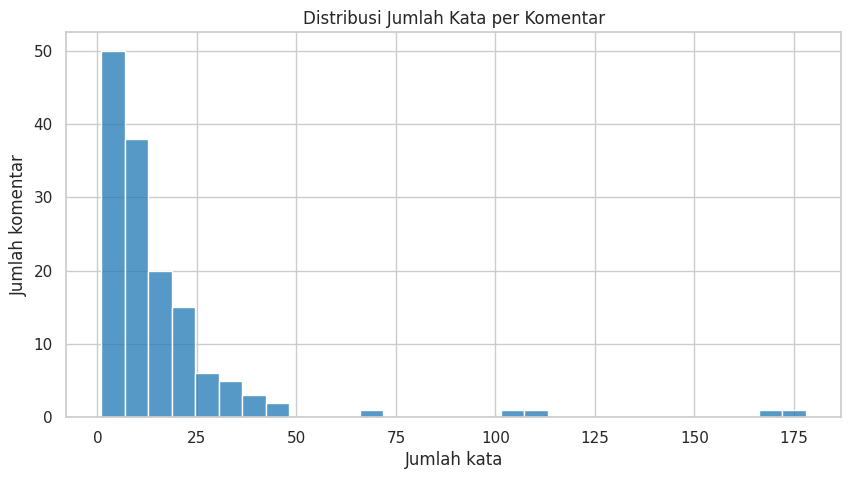

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="word_count",
    bins=30,
    color="#1f77b4"
)

plt.title("Distribusi Jumlah Kata per Komentar")
plt.xlabel("Jumlah kata")
plt.ylabel("Jumlah komentar")
plt.show()

# 4. Load Model

In [ ]:
# IMPORTANT NOTES: The model can't download properly so I had to download the model and locally stored the model
MODEL_NAME = "w11wo/indonesian-roberta-base-sentiment-classifier"
LOCAL_WEIGHT_FILE = "/content/model.safetensors"

device = 0 if torch.cuda.is_available() else -1

print("Device:", "GPU" if device == 0 else "CPU")
print("Loading config and tokenizer from Hugging Face...")

config = AutoConfig.from_pretrained(MODEL_NAME)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print("Loading local model.safetensors...")
state_dict = load_file(LOCAL_WEIGHT_FILE)

print("Loading local weights into the model...")
model = AutoModelForSequenceClassification.from_config(config)

model.eval()

sentiment_pipeline = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device
)

print("Model loaded successfully.")
print("Labels:", model.config.id2label)

del state_dict
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Device: GPU
Loading config and tokenizer from Hugging Face...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loading local model.safetensors...
Loading local weights into the model...
Model loaded successfully.
Labels: {0: 'positive', 1: 'neutral', 2: 'negative'}


# 5. Sentiment Analysis

In [ ]:
import os
import gc
import torch

from safetensors.torch import load_file
from transformers import (
    AutoConfig,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)

BATCH_SIZE = 32
MAX_LENGTH = 256

texts = df["clean_text"].tolist()

predictions = []

for start in range(0, len(texts), BATCH_SIZE):
    batch = texts[start:start + BATCH_SIZE]

    batch_predictions = sentiment_pipeline(
        batch,
        truncation=True,
        max_length=MAX_LENGTH,
        batch_size=BATCH_SIZE
    )

    predictions.extend(batch_predictions)

    if start % (BATCH_SIZE * 10) == 0:
        print(f"Progress: {min(start + BATCH_SIZE, len(texts))}/{len(texts)}")

df["sentiment_raw"] = [item["label"] for item in predictions]
df["sentiment_confidence"] = [item["score"] for item in predictions]

def standardize_sentiment(label):
    label = str(label).lower()

    if "positive" in label or label in ["label_2", "2"]:
        return "Positive"
    elif "negative" in label or label in ["label_0", "0"]:
        return "Negative"
    elif "neutral" in label or label in ["label_1", "1"]:
        return "Neutral"
    else:
        return label.title()

df["sentiment"] = df["sentiment_raw"].apply(standardize_sentiment)

sentiment_order = ["Positive", "Neutral", "Negative"]
df["sentiment"] = pd.Categorical(
    df["sentiment"],
    categories=sentiment_order,
    ordered=True
)

display(
    df[
        [
            "text",
            "sentiment",
            "sentiment_confidence",
            "likecount",
            "is_reply"
        ]
    ].head(20)
)

Progress: 32/144


,text,sentiment,sentiment_confidence,likecount,is_reply
0,22:33,Negative,0.350483,0,False
1,Singapura jir,Positive,0.386596,0,False
2,Petani libur ke luar negeri..Petani sawit😂😂,Positive,0.365086,0,False
3,Yg bisa dengerin full pidato prabowo\nMantap klian 👏,Positive,0.357570,0,False
4,Jawara indonesia\nKoparasi. Merah putih lanjutkan\nRakyat butuh untuk usaha yg\nPenting yg diberi kekuasaan baik\nDan di desa. Harus jelas untuk\nRakyat 🙏,Positive,0.356538,0,False
5,Ngmngnya berbelit2 pakk😂pusing aku 😮,Negative,0.374620,0,False
6,Omon omon itu lagi😂,Negative,0.371893,0,False
7,20:20 untuk doksli,Negative,0.364211,0,False
8,Siap2 Gerombolan tukang Gorengan siapkan kompor nyalakan api terus goreng Jangan lupa di kasih Bumbu2 penyedap😂😂,Positive,0.358877,0,False
9,hancur lagi IHSG,Positive,0.355778,0,False


# 6. Sentiment Summary

In [ ]:
sentiment_summary = (
    df.groupby("sentiment", observed=False)
    .agg(
        total_comments=("sentiment", "size"),
        percentage=("sentiment", lambda x: round(len(x) / len(df) * 100, 2)),
        total_likes=("likecount", "sum"),
        average_likes=("likecount", "mean"),
        average_confidence=("sentiment_confidence", "mean")
    )
    .reset_index()
)

sentiment_summary["average_likes"] = sentiment_summary["average_likes"].round(2)
sentiment_summary["average_confidence"] = sentiment_summary["average_confidence"].round(4)

display(sentiment_summary)

,sentiment,total_comments,percentage,total_likes,average_likes,average_confidence
0,Positive,92,63.89,0,0.0,0.3601
1,Neutral,0,0.00,0,NaN,NaN
2,Negative,52,36.11,0,0.0,0.3589


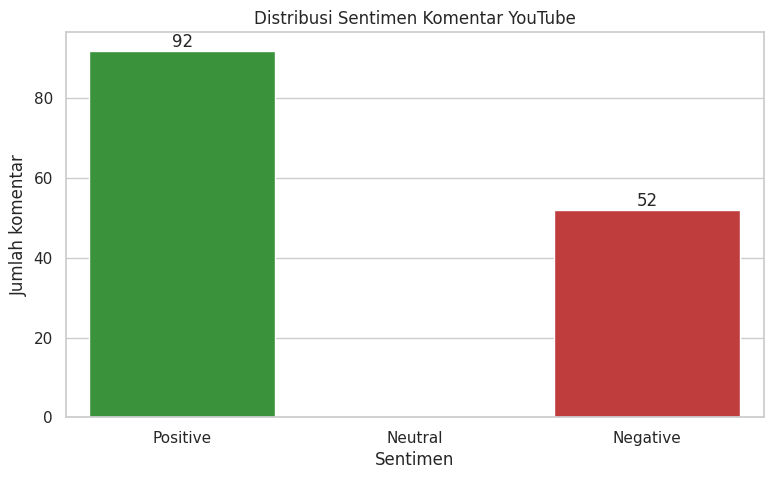

In [ ]:
colors = {
    "Positive": "#2ca02c",
    "Neutral": "#7f7f7f",
    "Negative": "#d62728"
}

plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df,
    x="sentiment",
    order=sentiment_order,
    palette=colors
)

plt.title("Distribusi Sentimen Komentar YouTube")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah komentar")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Sentimen komentar biasa vs replied

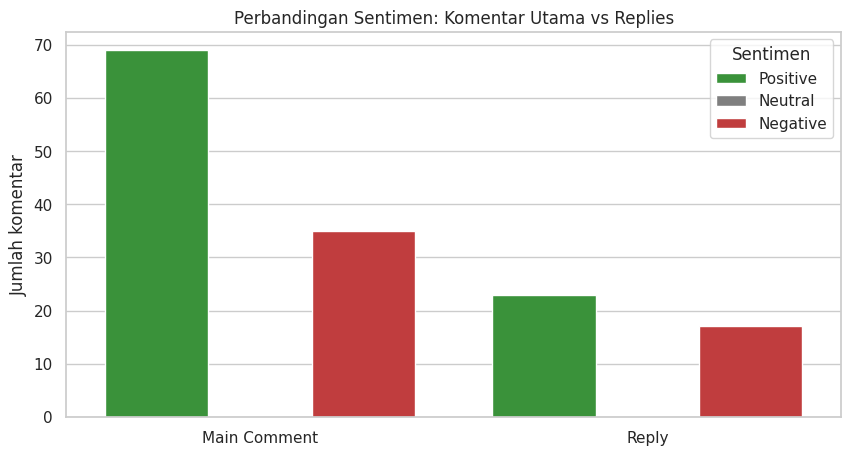

In [ ]:
reply_summary = (
    df.groupby(["is_reply", "sentiment"], observed=False)
    .size()
    .reset_index(name="total_comments")
)

reply_summary["comment_type"] = np.where(
    reply_summary["is_reply"],
    "Reply",
    "Main Comment"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=reply_summary,
    x="comment_type",
    y="total_comments",
    hue="sentiment",
    hue_order=sentiment_order,
    palette=colors
)

plt.title("Perbandingan Sentimen: Komentar Utama vs Replies")
plt.xlabel("")
plt.ylabel("Jumlah komentar")
plt.legend(title="Sentimen")
plt.show()

# 7. WordCloud per Sentiment

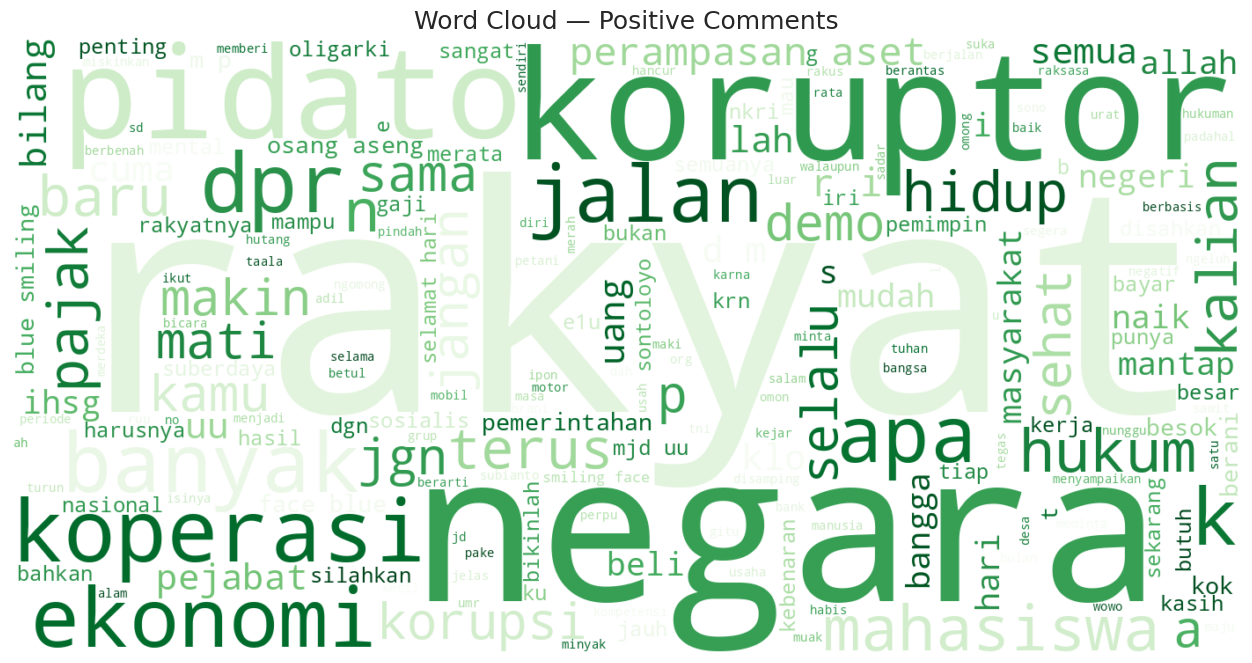

Tidak ada data untuk sentimen Neutral


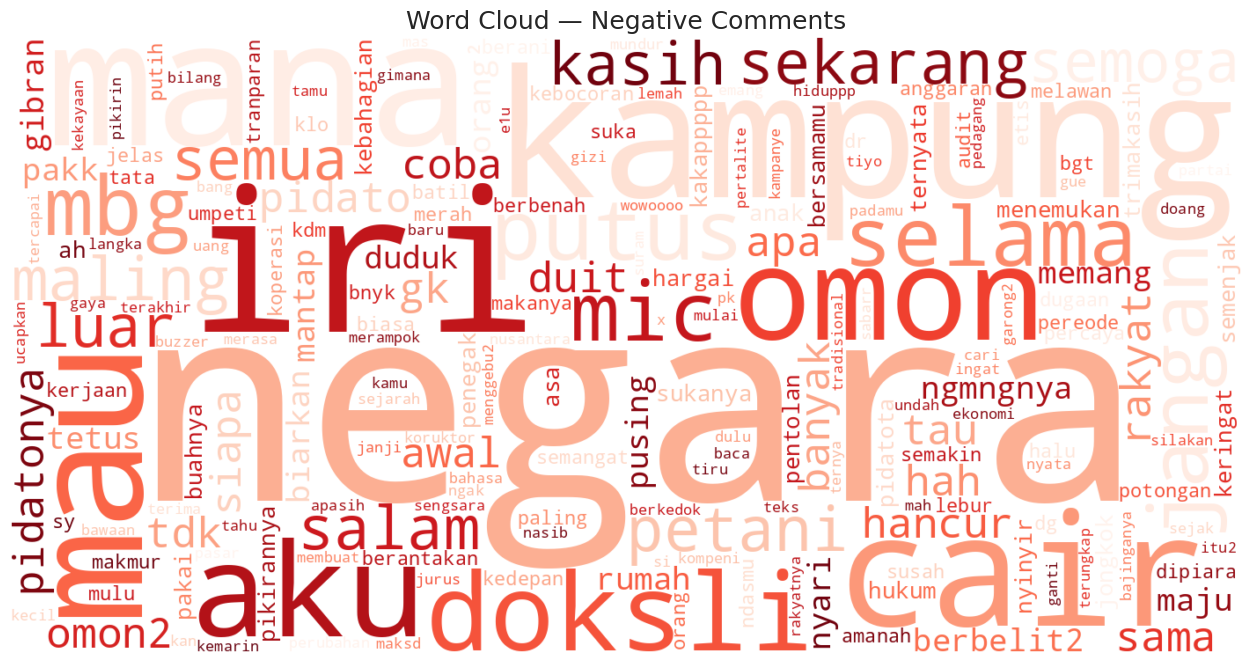

In [ ]:
stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stopword_factory.get_stop_words())

custom_stopwords = {
    "yg", "yang", "dan", "di", "ke", "dari", "ini", "itu", "nya",
    "pak", "bapak", "presiden", "prabowo", "indonesia", "ri",
    "untuk", "dengan", "saya", "kami", "kita", "aja", "gak",
    "ga", "tidak", "udah", "sudah", "kalo", "kalau", "jadi",
    "sih", "nya", "buat", "biar", "tp", "tapi"
}

all_stopwords = indonesian_stopwords.union(custom_stopwords)

def create_wordcloud(sentiment_label, color_map):
    text_data = " ".join(
        df.loc[df["sentiment"] == sentiment_label, "clean_text"].tolist()
    )

    if len(text_data.strip()) == 0:
        print(f"Tidak ada data untuk sentimen {sentiment_label}")
        return

    wordcloud = WordCloud(
        width=1400,
        height=700,
        background_color="white",
        stopwords=all_stopwords,
        colormap=color_map,
        min_font_size=10
    ).generate(text_data)

    plt.figure(figsize=(16, 8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud — {sentiment_label} Comments", fontsize=18)
    plt.show()

create_wordcloud("Positive", "Greens")
create_wordcloud("Neutral", "Greys")
create_wordcloud("Negative", "Reds")

# 8. Top kata per Sentiment

In [ ]:
def get_top_tfidf_terms(dataframe, sentiment_label, ngram_range=(1, 2), top_n=15):
    subset = dataframe.loc[
        dataframe["sentiment"] == sentiment_label,
        "clean_text"
    ].dropna()

    if len(subset) < 2:
        return pd.DataFrame(columns=["term", "tfidf_score"])

    vectorizer = TfidfVectorizer(
        stop_words=list(all_stopwords),
        ngram_range=ngram_range,
        min_df=2,
        max_df=0.90
    )

    matrix = vectorizer.fit_transform(subset)
    scores = np.asarray(matrix.mean(axis=0)).flatten()
    terms = vectorizer.get_feature_names_out()

    result = pd.DataFrame({
        "term": terms,
        "tfidf_score": scores
    })

    return result.sort_values("tfidf_score", ascending=False).head(top_n)

for label in sentiment_order:
    print(f"\nTop terms untuk {label}")
    display(get_top_tfidf_terms(df, label))


Top terms untuk Positive


,term,tfidf_score
147,rakyat,0.045073
139,pidato,0.036215
120,negara,0.034420
5,apa,0.032435
14,baru,0.030761
85,koruptor,0.030234
179,terus,0.029176
12,banyak,0.027902
99,mantap,0.027772
68,jgn,0.023825



Top terms untuk Neutral


,term,tfidf_score



Top terms untuk Negative


,term,tfidf_score
24,negara,0.056027
21,mau,0.050274
1,20,0.039264
2,22,0.038462
7,cair,0.038462
4,apa,0.038462
3,aku,0.038462
31,putus,0.032829
36,semoga,0.032829
0,10,0.030608


# 9. Evaluation Metrics: Low Confidence comments

In [ ]:
low_confidence_comments = (
    df.sort_values("sentiment_confidence", ascending=True)
    [
        [
            "text",
            "sentiment",
            "sentiment_confidence",
            "likecount",
            "is_reply"
        ]
    ]
    .head(50)
)

display(low_confidence_comments)

,text,sentiment,sentiment_confidence,likecount,is_reply
16,Sudahlah pak tua...\nNegeri ini makin kacau\nEkonomi makin hancur.,Positive,0.341412,0,False
29,KAMI PETANI BERSAMAMU PAK PRESIDEN SALAM SEMANGAT SALAM DUA PEREODE,Negative,0.341939,0,False
47,Makanya pak prabowo berbenah karena pak presiden tau bnyk kebocoran selama ini ..,Negative,0.342738,0,True
61,Sadarlah hey penghianat.... Presiden pelan tapi pasti akan hancurkan kekarakusanmu,Positive,0.344939,0,False
87,NGGEDABRUS,Positive,0.345094,0,False
27,Betul pak kebanyakan rakyat ke jebak PINJOL DAN RENTENIR,Positive,0.345271,0,False
71,Terimakasih banyak pak Prabowo Subianto presiden RI ❤❤❤,Positive,0.345867,0,False
106,Pak nasib pedagang dan pasar tradisional gimana pak presiden,Negative,0.346310,0,False
110,Terima kasih mas Tiyo ucapkan MBG maling berkedok gizi!!!! Ternya nyata !!! Terungkap sekarang,Negative,0.346446,0,False
67,"Ndasmuuuuuuu....Ngomong setinggi langit, tapi realitanya 5 persen..",Positive,0.347595,0,False


# 10. Save model and Manual Validation

In [ ]:
validation_df = pd.read_csv('/content/manual_validation.csv')

validation_df = validation_df.dropna(subset=["manual_sentiment"]).copy()

validation_df["manual_sentiment"] = validation_df["manual_sentiment"].str.strip().str.title()
validation_df["model_sentiment"] = validation_df["model_sentiment"].str.strip().str.title()

valid_labels = ["Positive", "Neutral", "Negative"]

validation_df = validation_df[
    validation_df["manual_sentiment"].isin(valid_labels)
].copy()

print(
    classification_report(
        validation_df["manual_sentiment"],
        validation_df["model_sentiment"],
        labels=valid_labels,
        zero_division=0
    )
)

accuracy = accuracy_score(
    validation_df["manual_sentiment"],
    validation_df["model_sentiment"]
)

print("Validation accuracy:", round(accuracy, 4))

              precision    recall  f1-score   support

    Positive       0.38      0.73      0.50        30
     Neutral       0.17      0.38      0.23        13
    Negative       0.50      0.09      0.15        55

    accuracy                           0.33        98
   macro avg       0.35      0.40      0.30        98
weighted avg       0.42      0.33      0.27        98

Validation accuracy: 0.3265


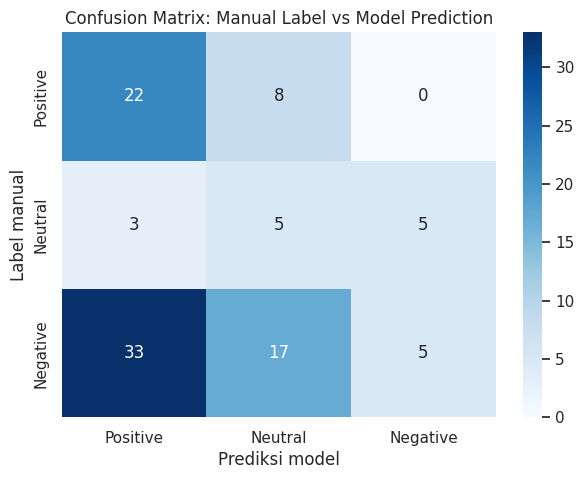

In [ ]:
cm = confusion_matrix(
    validation_df["manual_sentiment"],
    validation_df["model_sentiment"],
    labels=valid_labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=valid_labels,
    yticklabels=valid_labels
)

plt.title("Confusion Matrix: Manual Label vs Model Prediction")
plt.xlabel("Prediksi model")
plt.ylabel("Label manual")
plt.show()

# Conclusion

Sentiment analysis is useful for summarizing large volumes of text, but this notebook shows that model predictions must be validated carefully. Manual checking revealed substantial misclassification in politically nuanced YouTube comments, lowering the practical reliability of the results. This reinforces the importance of combining model outputs with human judgment before drawing conclusions.